In [30]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage, HumanMessage

load_dotenv()

True

In [31]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [32]:
from pydantic import BaseModel, Field

class EvaluationResult(BaseModel):

    score: int = Field(
        description="Quality score from 0 to 10"
    )

    evaluation: Literal["approved", "needs_improvement"] = Field(
        description="Whether the LinkedIn post approved the evaluation"
    )

    feedback: str = Field(
        description="Specific feedback for improving the post"
    )

In [33]:
evaluator_llm = llm.with_structured_output(EvaluationResult)

In [34]:
# state

class LinkedInState(TypedDict):

    topic : str
    post : str
    score : int
    evaluation : Literal["approved", "needs_improvement"]
    feedback : str
    iteration : int
    max_iteration : int
    

In [35]:
def generate_post(state: LinkedInState) -> LinkedInState:

    topic = state['topic']
    prompt = [SystemMessage(content="You are a smart linked in post text generator"), HumanMessage(content=f"Generate the linked in post on topic :: {topic}\n Rules :: \n post text has maximum 100 words. \n create simple and easy word post where you mention some random user project name and you use some hashtags too")]
    result = llm.invoke(prompt).content

    return {"post": result}


def evaluate_post(state: LinkedInState) -> LinkedInState:

    evaluation_prompt = [
    SystemMessage(
        content="""
    You are a strict LinkedIn post evaluator.

    Evaluate the generated LinkedIn post using the rules below:

    1. The post must contain a clear and relevant message about the given topic.
    2. The post must contain a project name.
    3. The project name should sound realistic and relevant to the topic.
    4. The post must use simple, clear, and easy-to-understand language.
    5. The post must contain relevant hashtags.
    6. The post must contain at least 3 hashtags.
    7. The post must not contain more than 100 words.
    8. The post should be professional and engaging.
    9. The post should not contain unnecessary repetition.
    10. The post should have a positive and confident LinkedIn-style tone.

    Return the evaluation in the following format:

    Score: <number from 0 to 10>

    Status: approved or needs_improvement

    Feedback:
    - <specific improvement or "No improvement needed">

    The post should receive approved only when:
    - Score is 8 or higher
    - All important rules are followed

    If the post needs_improvement, clearly explain what needs to be improved.
    Do not rewrite the post. Only evaluate it.
    """
    ),

    HumanMessage(
            content=f"""
    Topic:
    {state["topic"]}

    Generated LinkedIn post:
    {state["post"]}
    """
        )
    ]

    result = evaluator_llm.invoke(evaluation_prompt)

    return {"score": result.score,"evaluation": result.evaluation,"feedback": result.feedback}

    
def optimize_post(state: LinkedInState) -> LinkedInState:

    prompt = [
        SystemMessage(
            content="""
        You are an expert LinkedIn post writer.

        Improve the previous LinkedIn post using the
        evaluator's feedback.

        Rules:
        - Maximum 100 words
        - Use simple and easy language
        - Include a realistic project name
        - Include at least 3 relevant hashtags
        - Keep a professional and engaging tone
        - Do not explain the changes
        - Return only the improved LinkedIn post
        """
        ),

        HumanMessage(
            content=f"""
        Topic:
        {state["topic"]}

        Previous post:
        {state["post"]}

        Evaluator feedback:
        {state["feedback"]}
        """
        )
    ]

    result = llm.invoke(prompt)

    return {
        "post": result.content,
        "iteration": state["iteration"] + 1
    }
    


In [36]:
def check_condition(state : LinkedInState) -> Literal["__end__", "optimize"]:

    if state["evaluation"].lower() == "approved" or state["iteration"] >= state["max_iteration"]:
        return "__end__"
    else:
        return "optimize"

In [37]:
graph = StateGraph(LinkedInState)

graph.add_node("generate",generate_post)
graph.add_node("evaluate",evaluate_post)
graph.add_node("optimize",optimize_post)

graph.add_edge(START, "generate")
graph.add_edge("generate", "evaluate")
graph.add_conditional_edges("evaluate",check_condition)
graph.add_edge("optimize", "evaluate")

workflow = graph.compile()

In [38]:
# execute the graph

initial_state = {"topic" : "Artificial Intelligence" , "iteration" : 1, "max_iteration" : 5}

final_state = workflow.invoke(initial_state)

print(final_state)

{'topic': 'Artificial Intelligence', 'post': 'Artificial Intelligence is rapidly reshaping our world! It’s incredible to see how AI is driving innovation across every sector. From enhancing productivity to creating entirely new possibilities, the future with AI is bright.\n\nI was particularly impressed by a project named "Synapse Insights," which uses AI for personalized learning. What AI trends or projects are catching your eye lately?\n\n#AI #ArtificialIntelligence #Innovation #TechTrends #FutureIsNow', 'score': 9, 'evaluation': 'approved', 'feedback': 'No improvement needed', 'iteration': 1, 'max_iteration': 5}


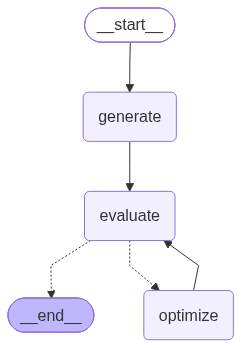

In [39]:
workflow